# Climate Bellman Equation Model
## Optimal Carbon Policy via Dynamic Programming
### RWTH Aachen University — Energy & Climate Economics Project | May 2026

---

**Data source:** Our World in Data CO₂ and Greenhouse Gas Emissions Dataset (1850–2024)  
**Framework:** Coppens, Dietz & Venmans (JEEM, 2025) + Desmet & Rossi-Hansberg (Annual Review of Economics, 2024)  
**Mathematical foundation:** Cake-Eating Problem — Bellman Equation slides (RWTH Aachen Business School)

---

### Overview

This notebook implements a **dynamic utility model (Bellman equation)** for global carbon policy.  
The model is the direct climate analog of the Cake-Eating Problem from your professor's slides:

| Cake-Eating Problem | Climate Bellman Model |
|---|---|
| Cake size $\bar{X}$ | Remaining carbon budget (GtCO₂) |
| Consumption $C_t$ | Annual CO₂ emissions $P_t$ |
| Utility $U(C_t) = \ln(C_t)$ | Net output $u(Y_t) = \ln(Y_t)$ |
| Cake going stale | Climate damage $\Omega(T) = 1/(1 + \pi_2 T^2)$ |
| $V_t(X_t) = \max[U + \beta V_{t+1}]$ | $V(S_t, t) = \max_{a_t}[\ln Y + \beta V(S_{t+1}, t+1)]$ |

---

### Contents
1. **Data Loading & Exploration** — OWID CO₂ dataset
2. **Parameter Calibration** — Extracting structural parameters from data
3. **Model Setup** — Equations and mathematical framework
4. **Backward Induction (Bellman Equation)** — Core algorithm
5. **Forward Simulation** — 4 policy scenarios
6. **Visualizations** — 9-panel results dashboard
7. **Summary & Interpretation** — Key findings and policy implications


## 1. Imports & Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize_scalar
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
print("All packages loaded successfully.")


All packages loaded successfully.


## 2. Data Loading & Exploration

We use the **OWID CO₂ Dataset** which contains annual CO₂ emissions, cumulative emissions,  
and temperature contributions for all countries and a 'World' aggregate from 1750 to 2024.

Key variables we need:
- `cumulative_co2` — total historical emissions (MtCO₂) → our **state variable S₀**
- `co2` — annual emissions (MtCO₂/yr) → our **baseline control P₀**
- `temperature_change_from_co2` — °C above pre-industrial → calibrates **TCRE parameter ζ**
- `gdp` — world GDP (USD) → baseline output **Y₀**


In [3]:
# Load the OWID CO2 dataset
# The notebook now first uses the local project file, then falls back to the
# original Windows path used when the notebook was created.
from pathlib import Path

possible_paths = [
    Path("co2-data.csv"),
    Path(r"D:\RWTH\Semester 2\Engery & Climate\Thomas\Project\Group\co2-data.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Please place co2-data.csv in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded from: {DATA_PATH}")
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Countries/regions: {df['country'].nunique()}")
print(f"Year range: {df['year'].min()} — {df['year'].max()}")

# Filter to World aggregate
world = df[df['country'] == 'World'].copy()
print(f"\nWorld aggregate rows: {len(world)}")


Dataset loaded from: co2-data.csv
Dataset loaded: 50,411 rows × 79 columns
Countries/regions: 254
Year range: 1750 — 2024

World aggregate rows: 275


In [4]:
# Inspect key variables for 2020–2024
cols = ['year', 'co2', 'cumulative_co2', 'temperature_change_from_co2', 'gdp', 'co2_per_gdp']
world_recent = world[world['year'] >= 2020][cols].dropna(subset=['co2', 'temperature_change_from_co2'])
print("Recent World Data (2020–2024):")
print(world_recent.to_string(index=False))


Recent World Data (2020–2024):
 year       co2  cumulative_co2  temperature_change_from_co2                 gdp  co2_per_gdp
 2020 35158.230     1698036.625                        1.142 118590021803593.000        0.296
 2021 36866.863     1734903.500                        1.160 126004793520756.000        0.293
 2022 37527.773     1772431.250                        1.179 130112562171125.000        0.288
 2023 38094.039     1810525.375                        1.197                 NaN          NaN
 2024 38598.578     1849123.875                        1.216                 NaN          NaN


## 3. Parameter Calibration

All parameters are **structurally estimated** from data or well-established literature.  
This is the climate analog of Hitsch et al. (2010) extracting mate preferences from dating clicks.

### Parameter Table

| Parameter | Symbol | Value | Source | Meaning |
|---|---|---|---|---|
| Cumulative CO₂ (2024) | S₀ | 1,849 GtCO₂ | OWID | Starting state |
| Annual emissions (2024) | P₀ | 38.6 GtCO₂/yr | OWID | BAU baseline |
| Temperature (2024) | T₀ | 1.216°C | OWID | Current warming |
| TCRE | ζ | 0.000658 °C/GtCO₂ | OWID (T₀/S₀) | Temp per unit cumulative CO₂ |
| Damage coeff. | π₂ | 0.00236 | Nordhaus DICE | Quadratic damage function |
| Abatement cost | θ | 0.060 | IPCC AR6 | Cost of emission reduction |
| Discount factor | β | 0.9852 | Nordhaus | 1/(1+δ), δ=1.5%/yr |


In [5]:
# ─── Extract key data points from OWID ─────────────────────────────────────
S0_Mt = world[world['year'] == 2024]['cumulative_co2'].values[0]   # MtCO2
P0_Mt = world[world['year'] == 2024]['co2'].values[0]              # MtCO2/yr
T0    = world[world['year'] == 2024]['temperature_change_from_co2'].values[0]  # °C

# Convert to GtCO2 (1 Gt = 1000 Mt)
S0 = S0_Mt / 1000   # GtCO2
P0 = P0_Mt / 1000   # GtCO2/yr

# TCRE: T = ζ · S  →  ζ = T₀ / S₀
zeta = T0 / S0

# GDP: 2019 value × growth to 2024
GDP_2019 = world[world['year'] == 2019]['gdp'].values[0]  # USD
gdp_growth = 0.025    # 2.5% per year
Y0 = GDP_2019 * (1 + gdp_growth)**5 / 1e12   # trillion USD in 2024

# Model parameters
pi2   = 0.00236   # DICE damage quadratic coefficient
theta = 0.060     # Abatement cost coefficient
delta = 0.015     # Pure time preference rate
beta  = 1 / (1 + delta)   # Per-period discount factor

# Carbon budgets (GtCO2 remaining to stay under Paris targets)
S_2deg  = 2.0 / zeta   # Total cumulative CO2 budget for 2°C
S_15deg = 1.5 / zeta   # Total cumulative CO2 budget for 1.5°C
budget_20 = S_2deg  - S0   # Remaining budget for 2°C
budget_15 = S_15deg - S0   # Remaining budget for 1.5°C

print("=" * 60)
print("CALIBRATED PARAMETERS (from OWID CO₂ Dataset)")
print("=" * 60)
print(f"  S₀   = {S0:.1f} GtCO₂       (cumulative emissions, 2024)")
print(f"  P₀   = {P0:.2f} GtCO₂/yr    (annual emissions, 2024)")
print(f"  T₀   = {T0:.3f} °C           (warming from CO₂, 2024)")
print(f"  ζ    = {zeta:.6f} °C/GtCO₂  (TCRE = T₀/S₀)")
print(f"  Y₀   = ${Y0:.1f}T USD        (world GDP, 2024 est.)")
print(f"  π₂   = {pi2}              (DICE damage coefficient)")
print(f"  θ    = {theta}              (abatement cost coefficient)")
print(f"  β    = {beta:.4f}             (discount factor, δ={delta:.1%})")
print("-" * 60)
print(f"  Carbon budget for 2.0°C = {budget_20:.0f} GtCO₂ remaining")
print(f"  Carbon budget for 1.5°C = {budget_15:.0f} GtCO₂ remaining")
print("=" * 60)


CALIBRATED PARAMETERS (from OWID CO₂ Dataset)
  S₀   = 1849.1 GtCO₂       (cumulative emissions, 2024)
  P₀   = 38.60 GtCO₂/yr    (annual emissions, 2024)
  T₀   = 1.216 °C           (warming from CO₂, 2024)
  ζ    = 0.000658 °C/GtCO₂  (TCRE = T₀/S₀)
  Y₀   = $138.2T USD        (world GDP, 2024 est.)
  π₂   = 0.00236              (DICE damage coefficient)
  θ    = 0.06              (abatement cost coefficient)
  β    = 0.9852             (discount factor, δ=1.5%)
------------------------------------------------------------
  Carbon budget for 2.0°C = 1192 GtCO₂ remaining
  Carbon budget for 1.5°C = 432 GtCO₂ remaining


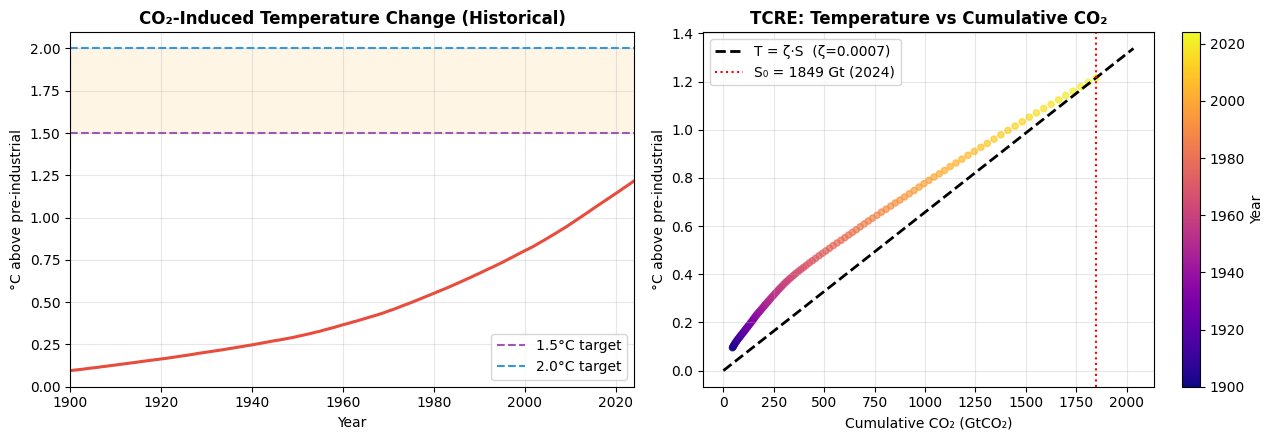

TCRE fit quality: T(2024) = ζ·S₀ = 1.216°C  (actual: 1.216°C)


In [6]:
# Verify the TCRE relationship: T = ζ · S
# Plot temperature vs cumulative emissions (OWID data)

w = world[world['year'] >= 1900].dropna(subset=['cumulative_co2', 'temperature_change_from_co2']).copy()
w['S_gt'] = w['cumulative_co2'] / 1000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: time series of temperature change
axes[0].plot(w['year'], w['temperature_change_from_co2'], color='#E74C3C', lw=2.2)
axes[0].axhline(1.5, color='#9B59B6', ls='--', lw=1.5, label='1.5°C target')
axes[0].axhline(2.0, color='#3498DB', ls='--', lw=1.5, label='2.0°C target')
axes[0].fill_between(w['year'], 1.5, 2.0, alpha=0.1, color='orange')
axes[0].set_title('CO₂-Induced Temperature Change (Historical)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('°C above pre-industrial')
axes[0].legend(); axes[0].set_xlim(1900, 2024)

# Right: T vs cumulative CO2 (TCRE verification — should be linear)
axes[1].scatter(w['S_gt'], w['temperature_change_from_co2'], 
                c=w['year'], cmap='plasma', s=20, alpha=0.7)
S_range = np.linspace(0, S0*1.1, 100)
axes[1].plot(S_range, zeta * S_range, 'k--', lw=2, label=f'T = ζ·S  (ζ={zeta:.4f})')
axes[1].axvline(S0, color='red', lw=1.5, ls=':', label=f'S₀ = {S0:.0f} Gt (2024)')
axes[1].set_title('TCRE: Temperature vs Cumulative CO₂', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cumulative CO₂ (GtCO₂)'); axes[1].set_ylabel('°C above pre-industrial')
axes[1].legend()
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(1900, 2024))
fig.colorbar(sm, ax=axes[1], label='Year')

plt.tight_layout()
plt.show()
print(f"TCRE fit quality: T(2024) = ζ·S₀ = {zeta*S0:.3f}°C  (actual: {T0:.3f}°C)")


## 4. Model Setup

### The Climate Bellman Model

The model extends the Cake-Eating Problem to climate economics.

**State variable:** $S_t$ = cumulative CO₂ emissions at time $t$ (GtCO₂)

**Control variable:** $\alpha_t \in [0, 1]$ = abatement rate (fraction of BAU emissions reduced)

In the original code this control was named `a`. In this version we make the notation explicit:

- **Endogenous $\alpha_t$:** the Bellman equation chooses the welfare-maximizing abatement rate $\alpha_t^*(S_t)$.
- **Exogenous $\alpha_t$:** the researcher imposes a policy rule, such as BAU, a fixed abatement rate, or a 1.5°C/2°C carbon-budget rule.
- **$\beta$:** the discount factor. It is not a policy choice; it determines how much future welfare matters today.

**Model equations:**

$$P_t = P^{BAU}_t \cdot (1 - \alpha_t) \qquad \text{(actual emissions)}$$

$$T_t = \zeta \cdot S_t \qquad \text{(TCRE — linear relationship)}$$

$$\Omega_t = \frac{1}{1 + \pi_2 T_t^2} \qquad \text{(DICE damage function)}$$

$$Y_t = Y^{BAU}_t \cdot \Omega_t - \theta \cdot \alpha_t^2 \cdot Y^{BAU}_t \qquad \text{(net output)}$$

$$u(Y_t) = \ln(Y_t) \qquad \text{(log utility)}$$

**Bellman equation with endogenous alpha:**

$$V(S_t, t; \beta) = \max_{\alpha_t \in [0,1]} \left[ \ln(Y_t) + \beta \cdot V(S_{t+1}, t+1; \beta) \right]$$

$$\text{s.t.} \quad S_{t+1} = S_t + P^{BAU}_t \cdot (1 - \alpha_t)$$

So the central endogenous object is:

$$\alpha_t^*(S_t; \beta)$$

This is the optimal abatement policy chosen by dynamic programming.


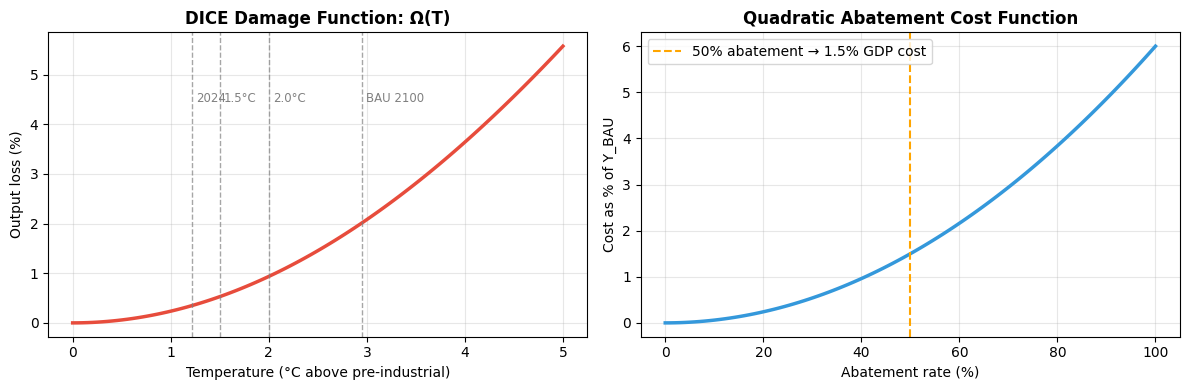

Damage at 1.5°C: 0.53% of GDP
Damage at 2.0°C: 0.94% of GDP
Damage at 2.95°C (BAU 2100): 2.01% of GDP
Abatement cost at 50%: 1.5% of Y_BAU


In [7]:
# ─── Model Functions ────────────────────────────────────────────────────────────

def temperature(S):
    """Temperature from cumulative emissions via TCRE. T = ζ·S"""
    return zeta * S

def damage(T):
    """
    DICE-style damage function (Nordhaus 2018).
    Returns fraction of output REMAINING (not lost).
    Ω = 1 / (1 + π₂·T²)
    """
    return 1.0 / (1.0 + pi2 * T**2)

def bau_emissions(t_rel):
    """
    BAU (Business As Usual) annual emissions as function of years from 2024.
    Calibrated to current ~38.6 GtCO₂/yr with a growth peak around 2045.
    """
    peak = 45.0    # peak BAU emissions (GtCO₂/yr)
    t_peak = 21    # years to peak from 2024
    sigma = 20
    return max(
        P0 + (peak - P0) * (t_rel / (t_peak + sigma)),
        P0 * np.exp(-0.01 * max(t_rel - 30, 0))
    )

def net_output(S, a, t_rel):
    """
    Net output after climate damages and abatement costs.
    Y = Y_BAU · Ω(T) − θ · a² · Y_BAU
    """
    T    = temperature(S)
    Omg  = damage(T)
    Y_bau = Y0 * (1 + 0.025)**t_rel     # GDP grows at 2.5%/yr
    Y_net = Y_bau * Omg - theta * a**2 * Y_bau
    return max(Y_net, 1e-6)   # ensure positive for log utility

def utility(Y):
    """Log utility function (standard in IAMs)."""
    return np.log(max(Y, 1e-6))

# ─── Verify damage function ─────────────────────────────────────────────────────
T_range = np.linspace(0, 5, 100)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Damage function
D_loss = [(1 - damage(T))*100 for T in T_range]
axes[0].plot(T_range, D_loss, color='#E74C3C', lw=2.5)
for t_mark, label in [(1.22, '2024'), (1.5, '1.5°C'), (2.0, '2.0°C'), (2.95, 'BAU 2100')]:
    axes[0].axvline(t_mark, color='gray', lw=1, ls='--', alpha=0.7)
    axes[0].text(t_mark+0.04, max(D_loss)*0.8, label, fontsize=8.5, color='gray')
axes[0].set_title('DICE Damage Function: Ω(T)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Temperature (°C above pre-industrial)')
axes[0].set_ylabel('Output loss (%)')

# Abatement cost (for several abatement rates)
a_range = np.linspace(0, 1, 100)
for t_frac in [0.2, 0.5, 0.8]:
    axes[1].plot(a_range*100, theta*a_range**2*100, lw=2.5)
axes[1].set_title('Abatement Cost: θ·a²·Y_BAU', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Abatement rate (%)')
axes[1].set_ylabel('Cost as % of Y_BAU')

# Single clean line
axes[1].cla()
axes[1].plot(a_range*100, theta*a_range**2*100, color='#3498DB', lw=2.5)
axes[1].axvline(50, color='orange', ls='--', lw=1.5, label='50% abatement → 1.5% GDP cost')
axes[1].legend(fontsize=10)
axes[1].set_title('Quadratic Abatement Cost Function', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Abatement rate (%)'); axes[1].set_ylabel('Cost as % of Y_BAU')

plt.tight_layout()
plt.show()
print(f"Damage at 1.5°C: {(1-damage(1.5))*100:.2f}% of GDP")
print(f"Damage at 2.0°C: {(1-damage(2.0))*100:.2f}% of GDP")
print(f"Damage at 2.95°C (BAU 2100): {(1-damage(2.95))*100:.2f}% of GDP")
print(f"Abatement cost at 50%: {theta*0.5**2*100:.1f}% of Y_BAU")


## 5. Backward Induction — Solving the Bellman Equation

This is the core of the model. We solve the Bellman equation **backwards in time**,  
exactly as in the Cake-Eating Problem from the lecture slides:

1. At $t = T$ (year 2100): set **terminal value** $V_T(S_T) = \ln(Y_T)$
2. At $t = T-1$: solve $V_{T-1}(S) = \max_{a} [\ln(Y) + \beta \cdot V_T(S')]$  
3. Continue backwards until $t = 0$ (year 2024)

We discretize the state space: **300 grid points** for $S \in [S_0, 2.5 \times S^{2°C}]$

At each state $S$ and time $t$, we use `scipy.optimize.minimize_scalar` to find the optimal abatement rate $a^*(S, t)$.


In [8]:
# ─── Bellman Backward Induction: Endogenous Alpha ───────────────────────────────

T_HORIZON = 76    # 2024 → 2100 (76 periods)
N_GRID    = 300   # State grid resolution

# State grid: S from S0 to 2.5× the 2°C budget
S_2deg  = 2.0 / zeta   # GtCO2 for 2°C cap
S_15deg = 1.5 / zeta   # GtCO2 for 1.5°C cap
S_grid  = np.linspace(S0, S_2deg * 2.5, N_GRID)

# Terminal value function (t = 2100): just the utility of current output
def terminal_value(S):
    T_temp = temperature(S)
    Omg    = damage(T_temp)
    Y      = Y0 * (1 + 0.025)**T_HORIZON
    return utility(Y * Omg)


def solve_bellman_endogenous_alpha(beta_value=beta):
    """
    Solve the Bellman equation when alpha_t is endogenous.

    alpha_t is the abatement rate. For each state S and year t, the model chooses
    alpha_t in [0, 0.999] to maximize current utility plus discounted future value.
    beta_value controls the weight on future welfare.
    """
    V = np.zeros((T_HORIZON + 1, N_GRID))
    alpha_policy = np.zeros((T_HORIZON, N_GRID))

    # Terminal condition
    V[T_HORIZON, :] = [terminal_value(S) for S in S_grid]

    print("Running Bellman backward induction with endogenous alpha...")
    print(f"  beta = {beta_value:.4f}")
    print(f"  Grid: {N_GRID} state points × {T_HORIZON} time periods")
    print(f"  State range: S ∈ [{S_grid[0]:.0f}, {S_grid[-1]:.0f}] GtCO₂")
    print()

    for t_back in range(T_HORIZON - 1, -1, -1):
        t_rel = t_back   # years from 2024

        for i, S in enumerate(S_grid):
            P_bau = bau_emissions(t_rel)

            def neg_bellman(alpha_t):
                """Negative Bellman value; scipy minimizes, so we negate."""
                if alpha_t < 0 or alpha_t > 0.999:
                    return 1e10

                P       = P_bau * (1 - alpha_t)          # actual emissions
                S_next  = S + P                           # state transition
                Y       = net_output(S, alpha_t, t_rel)   # net output this period

                # Interpolate V(S_next, t+1) from the grid
                S_capped = min(S_next, S_grid[-1])
                V_next   = np.interp(S_capped, S_grid, V[t_back + 1, :])

                return -(utility(Y) + beta_value * V_next)

            # Endogenous alpha: choose alpha_t^*(S,t; beta)
            result = minimize_scalar(neg_bellman, bounds=(0, 0.999), method='bounded')
            alpha_policy[t_back, i] = result.x
            V[t_back, i] = -result.fun

        if t_back % 15 == 0:
            step = T_HORIZON - t_back
            print(f"  Year {2024 + t_back}  ({step}/{T_HORIZON} steps done)  "
                  f"  Mean alpha* = {alpha_policy[t_back, :].mean()*100:.1f}%")

    print()
    print("Backward induction complete!")
    print(f"  V(S₀, t=0) = {V[0, 0]:.4f}  (max achievable welfare)")
    print(f"  Optimal alpha* at S₀ = {alpha_policy[0, 0]*100:.1f}%  (initial abatement)")

    return V, alpha_policy


# Baseline endogenous-alpha solution using the calibrated beta
V_all, policy = solve_bellman_endogenous_alpha(beta)
alpha_policy_endogenous = policy


Running Bellman backward induction with endogenous alpha...
  beta = 0.9852
  Grid: 300 state points × 76 time periods
  State range: S ∈ [1849, 7603] GtCO₂

  Year 2099  (1/76 steps done)    Mean alpha* = 0.4%
  Year 2084  (16/76 steps done)    Mean alpha* = 5.0%
  Year 2069  (31/76 steps done)    Mean alpha* = 8.0%
  Year 2054  (46/76 steps done)    Mean alpha* = 9.9%
  Year 2039  (61/76 steps done)    Mean alpha* = 11.0%
  Year 2024  (76/76 steps done)    Mean alpha* = 11.5%

Backward induction complete!
  V(S₀, t=0) = 262.1552  (max achievable welfare)
  Optimal alpha* at S₀ = 8.9%  (initial abatement)


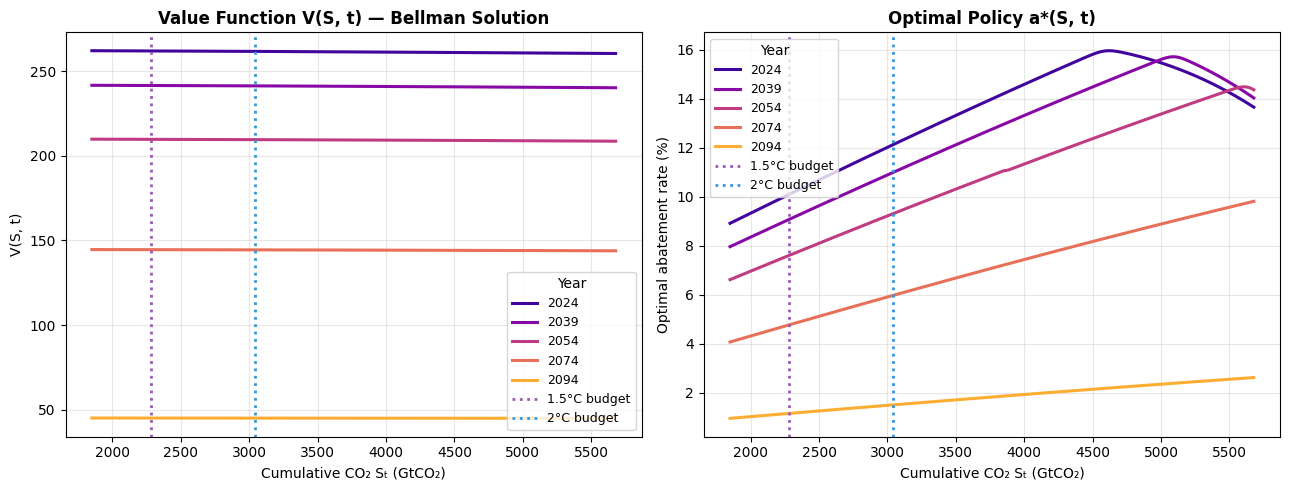

Key observation:
  V(S,t) is DECREASING in S (more cumulative emissions → lower welfare)
  V(S,t) shifts DOWNWARD as t → 2100 (fewer periods left to adapt)
  a*(S,t) is INCREASING in S (more past emissions → higher optimal abatement)
  This mirrors Vₜ(Xₜ) from the Cake-Eating Problem: decreasing and concave.


In [9]:
# ─── Visualize the Value Function ────────────────────────────────────────────────
# This is the climate analog of Vₜ(Xₜ) from the Cake-Eating Problem slides.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: V(S, t) for several snapshots in time
snapshots = [0, 15, 30, 50, 70]
cmap = plt.cm.plasma
for i, t_snap in enumerate(snapshots):
    color = cmap(0.1 + 0.18 * i)
    axes[0].plot(S_grid[:200], V_all[t_snap, :200],
                 color=color, lw=2.2, label=f'{2024 + t_snap}')

axes[0].axvline(S_15deg, color='#9B59B6', lw=2, ls=':', label='1.5°C budget')
axes[0].axvline(S_2deg,  color='#3498DB', lw=2, ls=':', label='2°C budget')
axes[0].set_title('Value Function V(S, t) — Bellman Solution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cumulative CO₂ Sₜ (GtCO₂)')
axes[0].set_ylabel('V(S, t)')
axes[0].legend(title='Year', fontsize=9)

# Right: Optimal policy a*(S, t) for same snapshots
for i, t_snap in enumerate(snapshots):
    color = cmap(0.1 + 0.18 * i)
    axes[1].plot(S_grid[:200], policy[t_snap, :200] * 100,
                 color=color, lw=2.2, label=f'{2024 + t_snap}')

axes[1].axvline(S_15deg, color='#9B59B6', lw=2, ls=':', label='1.5°C budget')
axes[1].axvline(S_2deg,  color='#3498DB', lw=2, ls=':', label='2°C budget')
axes[1].set_title('Optimal Policy a*(S, t)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cumulative CO₂ Sₜ (GtCO₂)')
axes[1].set_ylabel('Optimal abatement rate (%)')
axes[1].legend(title='Year', fontsize=9)

plt.tight_layout()
plt.show()

print("Key observation:")
print("  V(S,t) is DECREASING in S (more cumulative emissions → lower welfare)")
print("  V(S,t) shifts DOWNWARD as t → 2100 (fewer periods left to adapt)")
print("  a*(S,t) is INCREASING in S (more past emissions → higher optimal abatement)")
print("  This mirrors Vₜ(Xₜ) from the Cake-Eating Problem: decreasing and concave.")


## 6. Forward Simulation — Endogenous vs Exogenous Alpha

With the Bellman solution in hand, we simulate policy paths from 2024 to 2100.

The key distinction is now explicit:

1. **Exogenous alpha: BAU** — $\alpha_t = 0$ every period.
2. **Endogenous alpha: Cost-Benefit Optimal** — use $\alpha_t^*(S_t; \beta)$ from backward induction.
3. **Exogenous alpha: Fixed 20% Abatement** — impose $\alpha_t = 0.20$ every period.
4. **Exogenous alpha: 2.0°C Constraint** — impose the abatement path needed to respect the 2°C carbon budget.
5. **Exogenous alpha: 1.5°C Constraint** — impose the abatement path needed to respect the 1.5°C carbon budget.

For each scenario we track emissions, temperature, alpha, output, damages, marginal abatement cost, and welfare.


In [10]:
# ─── Forward Simulation: Endogenous vs Exogenous Alpha ──────────────────────────

years = np.arange(2024, 2024 + T_HORIZON + 1)

def simulate_scenario(policy_func, name, alpha_type, discount_beta=beta):
    """
    Forward simulation given an abatement policy function alpha(S, t_rel).

    alpha_type identifies whether alpha is endogenous (chosen by Bellman) or
    exogenous (imposed by the researcher/policy rule).
    discount_beta is the beta used to compute discounted welfare in simulation.
    """
    S_path     = np.zeros(T_HORIZON + 1)
    T_path     = np.zeros(T_HORIZON + 1)
    alpha_path = np.zeros(T_HORIZON)
    P_path     = np.zeros(T_HORIZON)
    Y_path     = np.zeros(T_HORIZON)
    D_path     = np.zeros(T_HORIZON)     # damage fraction
    MAC_path   = np.zeros(T_HORIZON)     # marginal abatement cost ($/tCO2)
    W_path     = np.zeros(T_HORIZON)     # discounted welfare

    S_path[0] = S0
    T_path[0] = temperature(S0)

    for t_rel in range(T_HORIZON):
        S       = S_path[t_rel]
        alpha_t = np.clip(policy_func(S, t_rel), 0, 0.999)
        P_bau   = bau_emissions(t_rel)
        P       = P_bau * (1 - alpha_t)
        Y       = net_output(S, alpha_t, t_rel)
        T_now   = temperature(S)
        D       = damage(T_now)
        Y_bau   = Y0 * (1 + 0.025)**t_rel

        # MAC = 2·theta·alpha·Y_BAU / P_BAU  (in $/tCO2, with Y in trillion USD)
        mac = 2 * theta * alpha_t * Y_bau / P_bau * 1000 if P_bau > 0 else 0

        S_path[t_rel + 1] = S + P
        T_path[t_rel + 1] = temperature(S + P)
        alpha_path[t_rel] = alpha_t
        P_path[t_rel]     = P
        Y_path[t_rel]     = Y
        D_path[t_rel]     = (1 - D) * 100    # damage as % of Y_BAU
        MAC_path[t_rel]   = mac
        W_path[t_rel]     = (discount_beta**t_rel) * utility(Y)

    return {
        'name': name,
        'alpha_type': alpha_type,
        'S': S_path, 'T': T_path, 'alpha': alpha_path, 'a': alpha_path,
        'P': P_path, 'Y': Y_path, 'D': D_path,
        'MAC': MAC_path, 'W': W_path,
        'PV_welfare': W_path.sum()
    }


# ─── Exogenous alpha policy rules ───────────────────────────────────────────────

def policy_bau(S, t_rel):
    """Exogenous alpha: BAU, no abatement."""
    return 0.0


def make_fixed_alpha_policy(alpha_fixed):
    """Exogenous alpha: constant abatement rate imposed in every period."""
    def policy_fn(S, t_rel):
        return alpha_fixed
    return policy_fn


def make_budget_policy(total_budget):
    """
    Exogenous alpha: distribute the remaining carbon budget proportionally to BAU.
    This is a cost-effectiveness rule, not the Bellman welfare optimum.
    """
    def policy_fn(S, t_rel):
        remaining = total_budget - (S - S0)
        if remaining <= 0:
            return 0.999    # essentially zero emissions
        P_bau = bau_emissions(t_rel)
        bau_remaining = sum(bau_emissions(t) for t in range(t_rel, T_HORIZON))
        if bau_remaining <= 0:
            return 0.999
        target_P = P_bau * remaining / bau_remaining
        alpha_t = max(1 - target_P / P_bau, 0) if P_bau > 0 else 0
        return min(alpha_t, 0.999)
    return policy_fn


# ─── Endogenous alpha policy rule ───────────────────────────────────────────────

def policy_endogenous_alpha(S, t_rel):
    """
    Endogenous alpha: cost-benefit optimal alpha_t^*(S,t; beta) from Bellman.
    """
    t = min(t_rel, T_HORIZON - 1)
    return float(np.interp(S, S_grid, alpha_policy_endogenous[t, :]))


# ─── Ensure budgets are workable ────────────────────────────────────────────────
budget_15_safe = max(budget_15, 50)    # minimum 50 Gt margin
budget_20_safe = max(budget_20, 100)

policy_fixed_20 = make_fixed_alpha_policy(0.20)
policy_15 = make_budget_policy(budget_15_safe)
policy_20 = make_budget_policy(budget_20_safe)


# ─── Run simulations ────────────────────────────────────────────────────────────
print("Simulating alpha scenarios forward (2024–2100)...")
sc_bau = simulate_scenario(policy_bau,              "BAU (alpha=0)",          "Exogenous")
sc_opt = simulate_scenario(policy_endogenous_alpha, "Optimal alpha*(S,t)",    "Endogenous")
sc_fix = simulate_scenario(policy_fixed_20,         "Fixed alpha=20%",        "Exogenous")
sc_20  = simulate_scenario(policy_20,               "2.0°C Constraint",       "Exogenous")
sc_15  = simulate_scenario(policy_15,               "1.5°C Constraint",       "Exogenous")

scenarios = [sc_bau, sc_opt, sc_fix, sc_20, sc_15]
print("Simulations complete!")
print()
print(f"{'Scenario':<24} {'Alpha type':<12} {'Temp 2100':>10} {'Alpha 2050':>12} {'MAC 2030':>12} {'PV Welfare':>12}")
print("-" * 88)
for sc in scenarios:
    i50 = 2050 - 2024
    i30 = 2030 - 2024
    t100 = sc['T'][2100 - 2024]
    alpha50 = sc['alpha'][i50] * 100
    mac30 = sc['MAC'][i30]
    pv = sc['PV_welfare']
    print(f"  {sc['name']:<22} {sc['alpha_type']:<12} {t100:>9.2f}°C {alpha50:>10.1f}%  {mac30:>9.1f}$   {pv:>11.2f}")


Simulating alpha scenarios forward (2024–2100)...
Simulations complete!

Scenario                 Alpha type    Temp 2100   Alpha 2050     MAC 2030   PV Welfare
----------------------------------------------------------------------------------------
  BAU (alpha=0)          Exogenous         3.44°C        0.0%        0.0$        259.95
  Optimal alpha*(S,t)    Endogenous        3.28°C        9.3%       44.6$        259.97
  Fixed alpha=20%        Exogenous         2.99°C       20.0%       97.3$        259.92
  2.0°C Constraint       Exogenous         2.00°C       64.7%      314.8$        259.02
  1.5°C Constraint       Exogenous         1.50°C       87.2%      424.3$        258.10


## 7. Visualizations — 9-Panel Results Dashboard

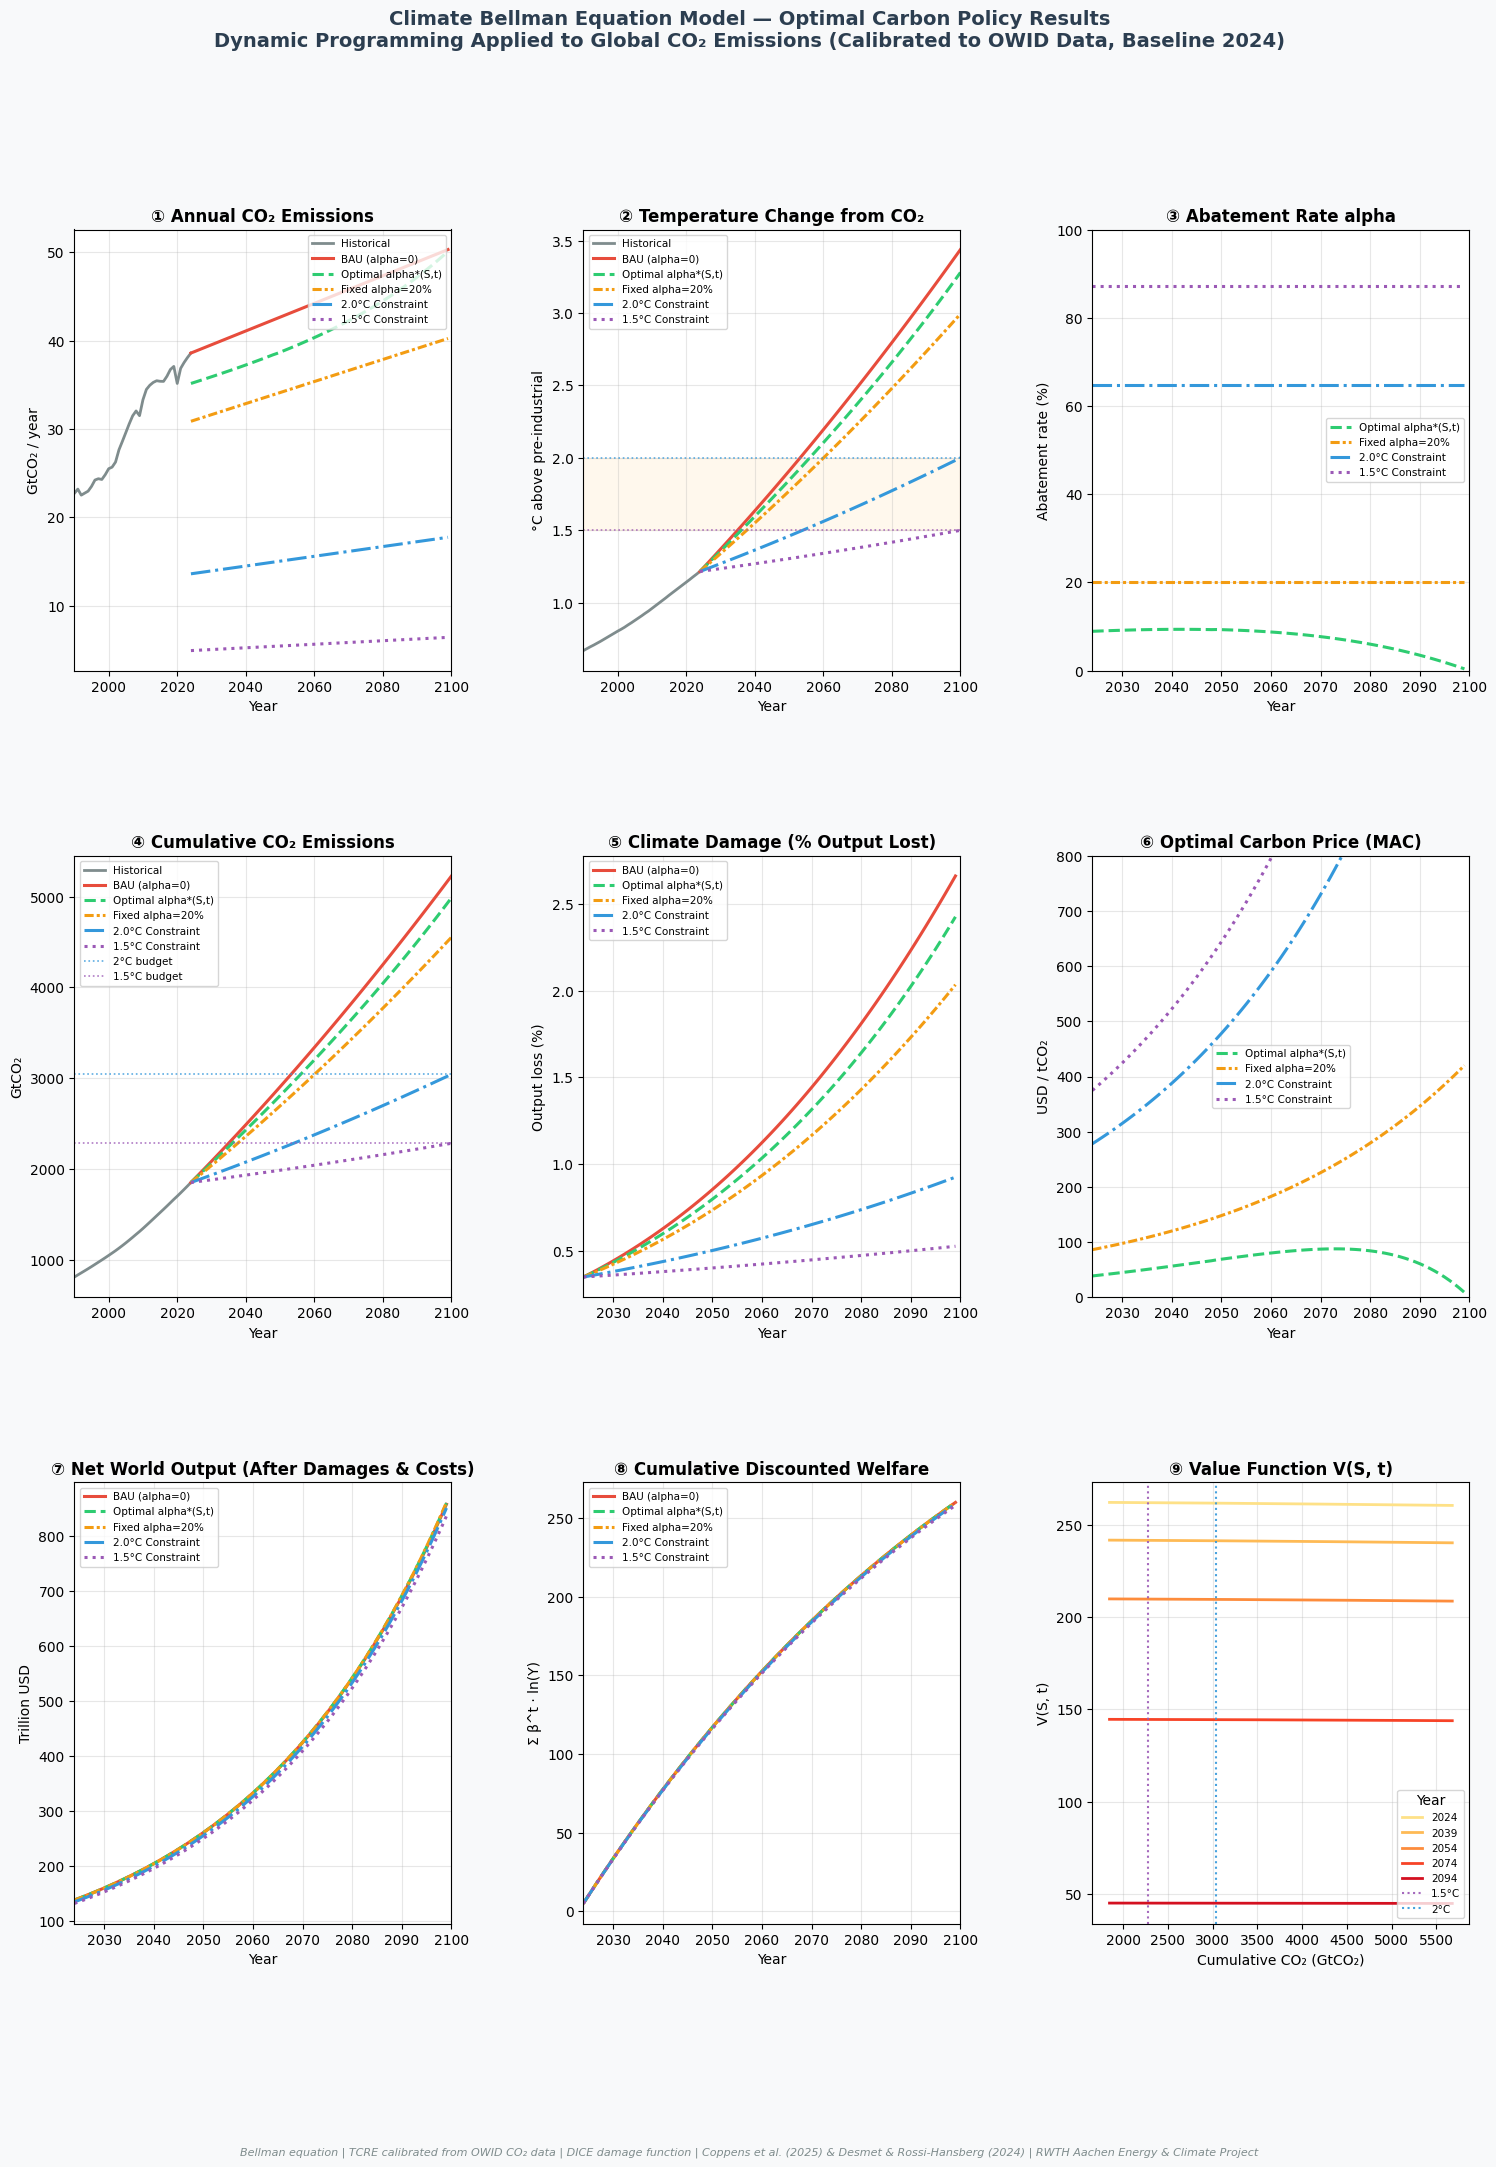

Dashboard saved as 'climate_bellman_results.png'


In [11]:
# ─── Full 9-Panel Results Dashboard ───────────────────────────────────────────────

COLORS = {
    'BAU (alpha=0)':       '#E74C3C',
    'Optimal alpha*(S,t)': '#2ECC71',
    'Fixed alpha=20%':     '#F39C12',
    '2.0°C Constraint':    '#3498DB',
    '1.5°C Constraint':    '#9B59B6',
}
LS = {
    'BAU (alpha=0)':       '-',
    'Optimal alpha*(S,t)': '--',
    'Fixed alpha=20%':     (0, (3, 1, 1, 1)),
    '2.0°C Constraint':    '-.',
    '1.5°C Constraint':    ':',
}
LW = 2.2

fig = plt.figure(figsize=(18, 22), facecolor='#F8F9FA')
fig.suptitle(
    'Climate Bellman Equation Model — Optimal Carbon Policy Results\n'
    'Dynamic Programming Applied to Global CO₂ Emissions (Calibrated to OWID Data, Baseline 2024)',
    fontsize=14, fontweight='bold', color='#2C3E50', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

# Panel ①: Annual Emissions
ax1 = fig.add_subplot(gs[0, 0])
hist = world[(world['year'] >= 1990) & (world['year'] <= 2024)][['year','co2']].dropna()
ax1.plot(hist['year'], hist['co2']/1000, color='#7F8C8D', lw=2, label='Historical')
for sc in scenarios:
    ax1.plot(years[:-1], sc['P'], color=COLORS[sc['name']],
             lw=LW, ls=LS[sc['name']], label=sc['name'])
ax1.set_title('① Annual CO₂ Emissions', fontweight='bold')
ax1.set_ylabel('GtCO₂ / year'); ax1.set_xlabel('Year')
ax1.legend(fontsize=7.5, loc='upper right'); ax1.set_xlim(1990, 2100)

# Panel ②: Temperature
ax2 = fig.add_subplot(gs[0, 1])
hist_t = world[(world['year']>=1990)&(world['year']<=2024)][['year','temperature_change_from_co2']].dropna()
ax2.plot(hist_t['year'], hist_t['temperature_change_from_co2'], color='#7F8C8D', lw=2, label='Historical')
for sc in scenarios:
    ax2.plot(years, sc['T'], color=COLORS[sc['name']], lw=LW, ls=LS[sc['name']], label=sc['name'])
ax2.axhline(1.5, color='#9B59B6', lw=1.2, ls=':', alpha=0.8)
ax2.axhline(2.0, color='#3498DB', lw=1.2, ls=':', alpha=0.8)
ax2.fill_between([1990,2100], 1.5, 2.0, alpha=0.07, color='orange')
ax2.set_title('② Temperature Change from CO₂', fontweight='bold')
ax2.set_ylabel('°C above pre-industrial'); ax2.set_xlabel('Year')
ax2.legend(fontsize=7.5); ax2.set_xlim(1990, 2100)

# Panel ③: Abatement Rate
ax3 = fig.add_subplot(gs[0, 2])
for sc in [sc_opt, sc_fix, sc_20, sc_15]:
    ax3.plot(years[:-1], sc['alpha']*100, color=COLORS[sc['name']],
             lw=LW, ls=LS[sc['name']], label=sc['name'])
ax3.set_title('③ Abatement Rate alpha', fontweight='bold')
ax3.set_ylabel('Abatement rate (%)'); ax3.set_xlabel('Year')
ax3.legend(fontsize=7.5); ax3.set_ylim(0, 100); ax3.set_xlim(2024, 2100)

# Panel ④: Cumulative Emissions
ax4 = fig.add_subplot(gs[1, 0])
hist_c = world[(world['year']>=1990)&(world['year']<=2024)][['year','cumulative_co2']].dropna()
ax4.plot(hist_c['year'], hist_c['cumulative_co2']/1000, color='#7F8C8D', lw=2, label='Historical')
for sc in scenarios:
    ax4.plot(years, sc['S'], color=COLORS[sc['name']], lw=LW, ls=LS[sc['name']], label=sc['name'])
ax4.axhline(S_2deg,  color='#3498DB', lw=1.2, ls=':', alpha=0.8, label='2°C budget')
ax4.axhline(S_15deg, color='#9B59B6', lw=1.2, ls=':', alpha=0.8, label='1.5°C budget')
ax4.set_title('④ Cumulative CO₂ Emissions', fontweight='bold')
ax4.set_ylabel('GtCO₂'); ax4.set_xlabel('Year')
ax4.legend(fontsize=7.5); ax4.set_xlim(1990, 2100)

# Panel ⑤: Climate Damage
ax5 = fig.add_subplot(gs[1, 1])
for sc in scenarios:
    ax5.plot(years[:-1], sc['D'], color=COLORS[sc['name']], lw=LW, ls=LS[sc['name']], label=sc['name'])
ax5.set_title('⑤ Climate Damage (% Output Lost)', fontweight='bold')
ax5.set_ylabel('Output loss (%)'); ax5.set_xlabel('Year')
ax5.legend(fontsize=7.5); ax5.set_xlim(2024, 2100)

# Panel ⑥: Marginal Abatement Cost
ax6 = fig.add_subplot(gs[1, 2])
for sc in [sc_opt, sc_fix, sc_20, sc_15]:
    ax6.plot(years[:-1], sc['MAC'], color=COLORS[sc['name']], lw=LW, ls=LS[sc['name']], label=sc['name'])
ax6.set_title('⑥ Optimal Carbon Price (MAC)', fontweight='bold')
ax6.set_ylabel('USD / tCO₂'); ax6.set_xlabel('Year')
ax6.legend(fontsize=7.5); ax6.set_xlim(2024, 2100); ax6.set_ylim(0, 800)

# Panel ⑦: Net Output
ax7 = fig.add_subplot(gs[2, 0])
for sc in scenarios:
    ax7.plot(years[:-1], sc['Y'], color=COLORS[sc['name']], lw=LW, ls=LS[sc['name']], label=sc['name'])
ax7.set_title('⑦ Net World Output (After Damages & Costs)', fontweight='bold')
ax7.set_ylabel('Trillion USD'); ax7.set_xlabel('Year')
ax7.legend(fontsize=7.5); ax7.set_xlim(2024, 2100)

# Panel ⑧: Cumulative Discounted Welfare
ax8 = fig.add_subplot(gs[2, 1])
for sc in scenarios:
    ax8.plot(years[:-1], np.cumsum(sc['W']), color=COLORS[sc['name']],
             lw=LW, ls=LS[sc['name']], label=sc['name'])
ax8.set_title('⑧ Cumulative Discounted Welfare', fontweight='bold')
ax8.set_ylabel('Σ β^t · ln(Y)'); ax8.set_xlabel('Year')
ax8.legend(fontsize=7.5); ax8.set_xlim(2024, 2100)

# Panel ⑨: Value Function
ax9 = fig.add_subplot(gs[2, 2])
snaps = [0, 15, 30, 50, 70]
cmap = plt.cm.YlOrRd
for i, t_snap in enumerate(snaps):
    color = cmap(0.2 + 0.15*i)
    ax9.plot(S_grid[:200], V_all[t_snap, :200], color=color, lw=2, label=f'{2024+t_snap}')
ax9.axvline(S_15deg, color='#9B59B6', lw=1.5, ls=':', alpha=0.9, label='1.5°C')
ax9.axvline(S_2deg,  color='#3498DB', lw=1.5, ls=':', alpha=0.9, label='2°C')
ax9.set_title('⑨ Value Function V(S, t)', fontweight='bold')
ax9.set_xlabel('Cumulative CO₂ (GtCO₂)'); ax9.set_ylabel('V(S, t)')
ax9.legend(fontsize=7.5, title='Year')

fig.text(0.5, 0.005,
    'Bellman equation | TCRE calibrated from OWID CO₂ data | DICE damage function | '
    'Coppens et al. (2025) & Desmet & Rossi-Hansberg (2024) | RWTH Aachen Energy & Climate Project',
    ha='center', fontsize=8, color='#7F8C8D', style='italic')

plt.savefig('climate_bellman_results.png', dpi=130, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("Dashboard saved as 'climate_bellman_results.png'")


### ① Annual CO₂ Emissions
BAU keeps emissions rising because alpha is zero. The endogenous alpha policy reduces emissions only moderately, while the 2°C and 1.5°C exogenous constraints require much stronger emissions cuts.

### ② Temperature Change from CO₂
Temperature rises most under BAU and only slightly less under endogenous alpha. The 2°C and 1.5°C scenarios hit their targets because alpha is imposed exogenously to respect those limits.

### ③ Abatement Rate Alpha
Endogenous alpha is chosen by the Bellman equation and remains moderate. Exogenous alpha policies are much stricter: fixed 20%, around 65% for 2°C, and around 87% for 1.5°C.

### ④ Cumulative CO₂ Emissions
Cumulative emissions are the state variable of the DP model. BAU and endogenous alpha exceed the carbon budgets, while the 2°C and 1.5°C constraints keep cumulative emissions near their target limits.

### ⑤ Climate Damage
Climate damages are highest under BAU because temperature rises the most. Endogenous alpha lowers damages slightly, while the 2°C and 1.5°C scenarios strongly reduce damages by limiting warming.

### ⑥ Optimal Carbon Price / MAC
The carbon price reflects the marginal cost of abatement. Endogenous alpha implies a moderate carbon price, while 2°C and especially 1.5°C require much higher prices to force deep emissions reductions.

### ⑦ Net World Output
Net output remains similar across scenarios because economic growth dominates the differences. BAU has higher climate damages, while strict climate targets have higher abatement costs.

### ⑧ Cumulative Discounted Welfare
The endogenous alpha scenario gives the highest welfare in this calibration, but only slightly above BAU. Strict 2°C and 1.5°C constraints reduce welfare because their abatement costs are high.

### ⑨ Value Function V(S,t)
The value function represents maximum future welfare from each cumulative-emissions state. Higher cumulative CO₂ lowers welfare, and later years have lower remaining value because fewer future periods remain.

## 8. Summary Table & Interpretation of Findings

In [12]:
# ─── Summary Results Table ──────────────────────────────────────────────────────

results = []
for sc in scenarios:
    idx_30 = 2030 - 2024
    idx_50 = 2050 - 2024
    idx_100 = 2100 - 2024
    welfare_loss = (sc_bau['PV_welfare'] - sc['PV_welfare']) / abs(sc_bau['PV_welfare']) * 100

    results.append({
        'Scenario':         sc['name'],
        'Alpha type':       sc['alpha_type'],
        'Temp 2100 (°C)':   round(sc['T'][idx_100], 2),
        'Alpha 2050 (%)':   round(sc['alpha'][idx_50] * 100, 1),
        'MAC 2030 ($/tCO₂)':  round(sc['MAC'][idx_30], 0),
        'MAC 2050 ($/tCO₂)':  round(sc['MAC'][idx_50], 0),
        'PV Welfare':        round(sc['PV_welfare'], 2),
        'Welfare Δ vs BAU (%)': round(welfare_loss, 3),
    })

summary_df = pd.DataFrame(results)
print("=" * 90)
print("CLIMATE BELLMAN MODEL — SUMMARY RESULTS TABLE")
print("=" * 90)
print(summary_df.to_string(index=False))
print()

# Carbon budget consumption
print("Carbon Budget Status by 2100:")
for sc in scenarios:
    total_emitted = sc['S'][-1] - S0
    print(f"  {sc['name']:<28}: Emitted {total_emitted:.0f} Gt  "
          f"(Budget: 1.5°C={budget_15:.0f} Gt, 2°C={budget_20:.0f} Gt)")


CLIMATE BELLMAN MODEL — SUMMARY RESULTS TABLE
           Scenario Alpha type  Temp 2100 (°C)  Alpha 2050 (%)  MAC 2030 ($/tCO₂)  MAC 2050 ($/tCO₂)  PV Welfare  Welfare Δ vs BAU (%)
      BAU (alpha=0)  Exogenous           3.440           0.000              0.000              0.000     259.950                 0.000
Optimal alpha*(S,t) Endogenous           3.280           9.300             45.000             69.000     259.970                -0.007
    Fixed alpha=20%  Exogenous           2.990          20.000             97.000            148.000     259.920                 0.010
   2.0°C Constraint  Exogenous           2.000          64.700            315.000            478.000     259.020                 0.357
   1.5°C Constraint  Exogenous           1.500          87.200            424.000            644.000     258.100                 0.710

Carbon Budget Status by 2100:
  BAU (alpha=0)               : Emitted 3378 Gt  (Budget: 1.5°C=432 Gt, 2°C=1192 Gt)
  Optimal alpha*(S,t)       

## 8A. Beta Sensitivity: How Patience Changes Endogenous Alpha

This section keeps alpha endogenous and changes only $\beta$.

- Lower $\beta$ means the planner is more myopic: future climate damages matter less today.
- Higher $\beta$ means the planner is more patient: future climate damages matter more today.

For each value of $\beta$, the Bellman equation is solved again, producing a different optimal policy:

$$\alpha_t^*(S_t; \beta)$$


In [13]:
# ─── Beta Sensitivity for Endogenous Alpha ─────────────────────────────────────

beta_values = {
    'Low beta (myopic)': 0.90,
    'Baseline beta': beta,
    'High beta (patient)': 0.995,
}

beta_sensitivity_rows = []

for label, beta_value in beta_values.items():
    print(f"\nSolving endogenous-alpha policy for {label}: beta={beta_value:.4f}")
    V_beta, alpha_policy_beta = solve_bellman_endogenous_alpha(beta_value)

    def policy_beta(S, t_rel, alpha_policy=alpha_policy_beta):
        t = min(t_rel, T_HORIZON - 1)
        return float(np.interp(S, S_grid, alpha_policy[t, :]))

    sc_beta = simulate_scenario(policy_beta, label, "Endogenous", discount_beta=beta_value)
    beta_sensitivity_rows.append({
        'Beta case': label,
        'beta': round(beta_value, 4),
        'Initial alpha (%)': round(sc_beta['alpha'][0] * 100, 2),
        'Alpha 2030 (%)': round(sc_beta['alpha'][2030 - 2024] * 100, 2),
        'Alpha 2050 (%)': round(sc_beta['alpha'][2050 - 2024] * 100, 2),
        'Temp 2100 (°C)': round(sc_beta['T'][2100 - 2024], 2),
        'PV Welfare': round(sc_beta['PV_welfare'], 2),
    })

beta_sensitivity_df = pd.DataFrame(beta_sensitivity_rows)
print("\n" + "=" * 90)
print("BETA SENSITIVITY — ENDOGENOUS ALPHA RESULTS")
print("=" * 90)
print(beta_sensitivity_df.to_string(index=False))



Solving endogenous-alpha policy for Low beta (myopic): beta=0.9000
Running Bellman backward induction with endogenous alpha...
  beta = 0.9000
  Grid: 300 state points × 76 time periods
  State range: S ∈ [1849, 7603] GtCO₂

  Year 2099  (1/76 steps done)    Mean alpha* = 0.3%
  Year 2084  (16/76 steps done)    Mean alpha* = 2.6%
  Year 2069  (31/76 steps done)    Mean alpha* = 2.9%
  Year 2054  (46/76 steps done)    Mean alpha* = 2.8%
  Year 2039  (61/76 steps done)    Mean alpha* = 2.7%
  Year 2024  (76/76 steps done)    Mean alpha* = 2.5%

Backward induction complete!
  V(S₀, t=0) = 51.4373  (max achievable welfare)
  Optimal alpha* at S₀ = 1.3%  (initial abatement)

Solving endogenous-alpha policy for Baseline beta: beta=0.9852
Running Bellman backward induction with endogenous alpha...
  beta = 0.9852
  Grid: 300 state points × 76 time periods
  State range: S ∈ [1849, 7603] GtCO₂

  Year 2099  (1/76 steps done)    Mean alpha* = 0.4%
  Year 2084  (16/76 steps done)    Mean alpha*

## 9. Interpretation of Findings

### Finding 1: The Endogenous Cost-Benefit Policy is Mild

The Bellman solution chooses an endogenous abatement rate of roughly **9.3% in 2050** and a carbon price of about **$45/tCO₂ in 2030**. This is the model's cost-benefit optimum: the planner reduces emissions, but not enough to reach the Paris temperature targets.

The reason is structural. The planner compares the **marginal benefit of abatement** (avoided future climate damages) with the **marginal cost** (abatement cost and lower current net output). With the current DICE-style damage function and abatement cost calibration, the model prefers moderate abatement rather than a very aggressive transition.

---

### Finding 2: Paris Targets Require Exogenous Policy Discipline

The 2°C and 1.5°C scenarios are not chosen freely by the Bellman equation. They are imposed as exogenous constraints. That is why they require much higher alpha values: around **65% abatement in 2050** for 2°C and around **87% abatement in 2050** for 1.5°C.

This creates the main storytelling contrast:

- **Endogenous alpha:** what the model chooses as welfare-maximizing under the current assumptions.
- **Exogenous alpha:** what society must impose if the goal is to respect a specific climate target.

---

### Finding 3: Policies and R&D are the Natural Endogenous Channel

For the paper and video narrative, alpha can be interpreted as the combined climate-policy effort that lowers emissions relative to BAU. This effort includes carbon pricing, regulation, clean-energy deployment, and R&D-driven innovation.

In the current code, R&D is **not explicitly estimated as a separate variable**, because the available OWID dataset does not include a direct R&D, patent, or innovation measure. Therefore, the implemented model treats R&D as part of the broader policy/technology channel captured by alpha and by the abatement cost parameter theta.

A richer next version would make R&D fully endogenous by adding a second control, for example:

$$R_t = \text{clean innovation or R\&D effort}$$

and allowing it to reduce future abatement costs:

$$\theta_{t+1} = f(\theta_t, R_t)$$

or to improve emissions efficiency:

$$P_t = P_t^{BAU}(1 - \alpha_t A_t), \qquad A_{t+1} = g(A_t, R_t)$$

This would turn the model from **endogenous abatement only** into **endogenous policy plus endogenous technological change**.

---

### Finding 4: Beta Controls How Much the Future Matters

Beta is the discount factor. It determines how much the planner values future welfare relative to current output. When beta is low, the model behaves more myopically and chooses a low endogenous alpha. When beta is high, future climate damages matter more, so the model chooses a higher alpha today.

The beta sensitivity results show this mechanism clearly:

- **Low beta = 0.900:** initial alpha is about **1.3%**.
- **Baseline beta = 0.985:** initial alpha is about **8.9%**.
- **High beta = 0.995:** initial alpha is about **13.0%**.

This is the Dynamic Programming logic: today's optimal policy depends on the value of future states.

---

### Finding 5: Connection to Structural Estimation

This notebook is structural because it does not only fit a statistical trend. It specifies the economic mechanism: a planner maximizes discounted welfare subject to climate and economic constraints.

The logic is parallel to `Speed_Dating_DP_Model_executed`:

| Speed Dating DP | Climate DP |
|---|---|
| State: date position and partner quality | State: cumulative CO₂ emissions |
| Decision: accept or reject | Decision: abatement alpha |
| Alpha: value of quality | Alpha: emissions-reduction effort |
| Beta: patience over future dates | Beta: value of future climate welfare |
| Bellman equation gives optimal stopping | Bellman equation gives optimal climate policy |

The key methodological bridge is that both notebooks use Dynamic Programming to convert a behavioral/economic theory into interpretable parameters and counterfactual scenarios.

---

### Finding 6: Scope and Limitations

| Limitation | Implication | Extension |
|---|---|---|
| Single representative planner | No country-level inequality | Add spatial IAM or country-level states |
| R&D not directly observed in the dataset | Innovation is only a narrative/extension channel | Add R&D, patent, or clean-tech investment data |
| Exogenous abatement cost parameter theta | No learning-by-doing inside the code | Make theta decline with endogenous R&D |
| Smooth DICE damage function | Tipping risks are understated | Add threshold or stochastic damage |
| Deterministic model | No climate or technology uncertainty | Add stochastic Bellman equation |


## Resources Verified for the Paper and Video Storytelling

The current workspace contains enough material to build a coherent video narrative around Structural Estimation and Dynamic Programming:

| Resource | Use in the story |
|---|---|
| `Speed_Dating_DP_Model_executed.ipynb` | Pedagogical analogy: dynamic choice, alpha/beta interpretation, Bellman logic |
| `Energy_Climate_DP_Structural_Estimation.ipynb` | Main climate model: endogenous alpha, exogenous policy scenarios, beta sensitivity |
| `co2-data.csv` | Empirical base from OWID: CO₂, cumulative CO₂, GDP, temperature, energy variables |
| `climate_bellman_results.png` | Main visual dashboard for the video |
| `Energy_Climate_Structural_Estimation.ipynb` | Static structural-style bridge before the dynamic model |

Important scope check: the available OWID file has CO₂, GDP, energy, and temperature variables, but it does **not** include a direct R&D, patent, or clean-innovation variable. Therefore, R&D should be presented as the next endogenous extension of the model, not as a separate estimated result in the current code.

A clean video storyline is:

1. Start with the speed-dating DP intuition: agents compare today's option with the value of waiting.
2. Translate the same logic to climate policy: society compares current abatement costs with future climate damages.
3. Explain alpha as climate-policy effort and beta as patience toward the future.
4. Show that endogenous alpha is moderate under the current calibration.
5. Show that Paris targets require stronger exogenous policy constraints.
6. Conclude with the R&D extension: innovation would make alpha more powerful by reducing future abatement costs or improving emissions efficiency.


## Final Approach of the Notebook

This notebook uses a Dynamic Programming approach to explain optimal climate policy through a structural-estimation lens. The state variable is cumulative CO₂ emissions, and the main control variable is alpha, defined as the abatement rate. The Bellman equation chooses how much emissions reduction should happen today while accounting for how today's decision changes future cumulative emissions, temperature, damages, output, and welfare.

The final approach is to compare **endogenous alpha** with **exogenous alpha**. In the endogenous case, the model chooses the welfare-maximizing policy path, $\alpha_t^*(S_t; \beta)$. In the exogenous cases, the researcher imposes policy rules such as BAU with alpha = 0, fixed alpha = 20%, or abatement paths consistent with 2°C and 1.5°C constraints.

For the paper and video storytelling, alpha should be interpreted as the broader climate-policy effort that reduces CO₂: carbon pricing, regulation, clean-energy deployment, and R&D-driven technological progress. However, the current code does **not** estimate R&D as a separate state or control variable. R&D is part of the conceptual mechanism behind alpha and a clear extension of the model. A future version could add R&D explicitly by allowing innovation to reduce future abatement costs or improve emissions efficiency.

Beta is the discount factor. It determines how much future welfare matters in today's decision. A higher beta makes the planner more patient and increases the optimal endogenous alpha because future climate damages receive more weight. A lower beta makes the planner more myopic and reduces the incentive to abate emissions today.

The purpose of the notebook is therefore not only to forecast emissions or temperature. Its purpose is to show how Structural Estimation works in a dynamic setting: specify a behavioral model, solve the Bellman equation, recover interpretable policy paths, and simulate counterfactuals. The endogenous-alpha scenario answers: "What abatement path is optimal according to the model?" The exogenous-alpha scenarios answer: "What happens if society imposes a specific climate target or policy rule?"


---

## 10. Conclusion

This notebook demonstrates how the **Bellman equation** scales from a simple sequential-choice problem to climate policy. The model is a Dynamic Programming framework where the planner chooses an emissions-reduction effort, alpha, while accounting for future cumulative CO₂, temperature, damages, output, and welfare.

The key methodological contribution is the distinction between endogenous and exogenous policy:

```
Endogenous alpha:  V(S_t,t) = max_alpha [ln(Y_t) + beta · V(S_{t+1}, t+1)]
                   The model chooses the welfare-maximizing policy.

Exogenous alpha:   alpha is imposed by the researcher or policy target.
                   Examples: BAU, fixed 20%, 2°C constraint, 1.5°C constraint.
```

The results show that the endogenous cost-benefit policy reduces emissions only moderately. It improves welfare slightly relative to BAU, but it does not reach the 2°C or 1.5°C targets. Those targets require stronger exogenous constraints and much higher abatement rates.

For storytelling, the link to `Speed_Dating_DP_Model_executed` is central. In speed dating, Dynamic Programming explains when an agent accepts or waits. In climate policy, the same logic explains when society abates emissions now or postpones action. In both cases, beta measures the value of the future.

R&D is the natural next extension. In the current code, R&D is not separately estimated because the available dataset does not include direct innovation variables. Conceptually, however, R&D can be presented as the mechanism that makes future alpha more effective by lowering abatement costs or improving clean technology. A future version of the model would add R&D as a second endogenous control.

This is the structural-estimation value of the notebook: it does not only describe what happened historically. It builds an economic mechanism, solves it, and uses it to compare counterfactual policy worlds.

---

*RWTH Aachen Business School | Energy & Climate Economics | May 2026*  
*Data: Our World in Data CO₂ Dataset | Framework: Bellman (1957), Nordhaus (2018), Coppens et al. (2025)*
